# 计算态演化

## 薛定谔演化

### 格式1：使用函数 `evolve_and_measure`


In [2]:
import quante as qt

qt.basicfun.clear_numba_cache()

In [1]:
import quante as qt
import numpy as np
op = qt.generate.operas.spin

L = 10
basis = qt.generate.basis.spin_basis(L=L, Nup=L//2)

# Model
J, γ = 1., 0.5
builder = op.builder()
for l in range(L-1):
    builder += '+-', [l+1, l], 1/2 * (J + γ),
    builder += '+-', [l, l+1], 1/2 * (J - γ),
ham = builder.build()
hammat = ham.to_matrix(basis=basis, pauli=False, sparse=True)

tlist = np.linspace(0, 40, 200)
init_state = qt.generate.state.neel(L=L, down_first=True, Nup=L//2)
# init_state = qt.generate.state.product_state("1"+"0"*(L-1), Nup=1)
obsoper = [op.z(i).to_matrix(basis=basis, pauli=False, sparse=True) for i in range(L)]
# obsoper = [op.z(0).to_matrix(basis=basis, sparse=True), 
#            op.z(1).to_matrix(basis=basis, sparse=True)]  # todo dense matrix

result_time_obs = qt.linalg.evolve_and_measure(
    hammat, init_state, tlist,
    measure=obsoper,
    method="RK45"
)

100%|##########| 200/200 [00:00<00:00, 815.95it/s]


### 格式2：使用函数 `EvolveEngine().measure()`

可以调用的方法不包含 `eig`

array([ 0.5       ,  0.49486073,  0.47960136,  0.45469179,  0.4208973 ,  0.37925233,  0.33102523,  0.27767502,  0.22080193,  0.16209336,  0.10326729,  0.04601509, -0.00805413, -0.05746578, -0.10092665, -0.13736496, -0.16596212, -0.18617517, -0.19774929, -0.20072006, -0.19540554, -0.18238865, -0.1624906 , -0.13673649, -0.10631444, -0.07252975, -0.03675585, -0.00038369,  0.03522847,  0.06880321,  0.0991884 ,  0.12539629,  0.14663604,  0.16233843,  0.17217203,  0.17605022,  0.17412876,  0.1667942 ,  0.15464343,  0.13845519,  0.11915471,  0.0977728 ,  0.07540102,  0.05314478,  0.03207624,  0.01318883, -0.00264448, -0.01470768, -0.0224714 , -0.02561444, -0.02403646, -0.01786113, -0.00742985,  0.00671378,  0.02384797,  0.04310411,  0.06350422,  0.08400279,  0.10353132,  0.12104358,  0.13556   ,  0.14620909,  0.15226454,  0.15317653,  0.14859598,  0.13839103,  0.12265507,  0.10170613,  0.07607771,  0.04650138,  0.01388179, -0.02073491, -0.05619826, -0.09129483, -0.1247924 , -0.15548527, -0.18

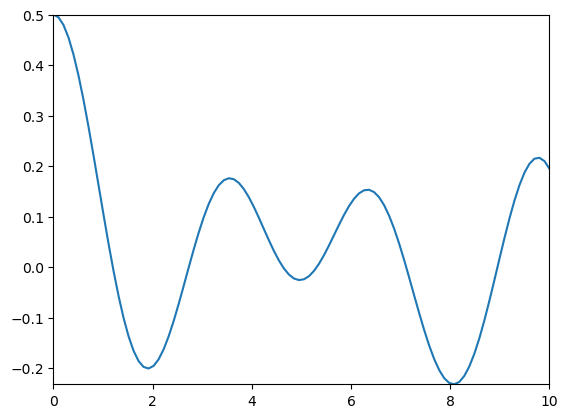

In [2]:
import numpy as np
import quante as qt
op = qt.generate.operas.spin
tlist = np.linspace(0, 10, 100)

# Model
L=10
J, γ = 1., 0.1
builder = op.builder()
for l in range(L-1):
    builder += "+-", [l+1, l], (J+γ)/2
    builder += "+-", [l, l+1], (J-γ)/2
ham = builder.build()

basis = qt.generate.basis.spin_basis(L=L)
hammat = ham.to_matrix(basis=basis, pauli=False, sparse=True)

# Observation
obsmatlist = [op.z(L//2).to_matrix(basis, pauli=False, sparse=True)]
init_state = qt.generate.state.neel(L=L, down_first=True)

# Plot
evolve_engine = qt.linalg.EvolveEngine(
    hammat, init_state, ts=tlist, normalize=True
)
res = evolve_engine.plot_measure(obsmatlist)  # 使用 plot_measure 可以直接绘图
res

不同方法的结果对比

In [3]:
import quante as qt
import numpy as np
op = qt.generate.operas.spin

L = 10
basis = qt.generate.basis.spin_basis(L=L, Nup=L//2)

# Model
J, γ = 1., 0.
builder = op.builder()
for l in range(L-1):
    builder += '+-', [l+1, l], 1/2 * (J + γ),
    builder += '+-', [l, l+1], 1/2 * (J - γ),
ham = builder.build()
hammat = ham.to_matrix(basis=basis, pauli=False, sparse=False)

tlist = np.linspace(0, 10, 200)
init_state = qt.generate.state.neel(L=L, down_first=True, Nup=L//2)
obsoper = [op.z(i).to_matrix(basis=basis, pauli=False, sparse=True) for i in range(L)]

res = qt.linalg.evolve_and_measure(hammat, init_state, tlist, measure=obsoper, method='eig-cpu')
# res1 = qt.linalg.evolve_and_measure(hammat, init_state, tlist, measure=obsoper, method='eig-cuda:0')
res2 = qt.linalg.evolve_and_measure(hammat, init_state, tlist, measure=obsoper, method='mul-cpu')
# res3 = qt.linalg.evolve_and_measure(hammat, init_state, tlist, measure=obsoper, method='mul-cuda:0')
res4 = qt.linalg.evolve_and_measure(hammat, init_state, tlist, measure=obsoper, method='RK45')
# list(map(np.linalg.norm, [res1 - res, res2 - res, res3 - res, res4 - res]))

100%|##########| 200/200 [00:00<00:00, 1456.13it/s]


## 主方程演化

PHYSICAL REVIEW LETTERS 127, 070402 (2021)

$$
    \mathcal{L}(\rho) = -i [H, \rho] + \sum_{l} L_l \rho L_l^{\dagger} - \frac{1}{2} \sum_{l} (L_l^{\dagger} L_l \rho + \rho L_l^{\dagger} L_l)
$$

100%|##########| 5/5 [00:00<00:00, 75.55it/s]


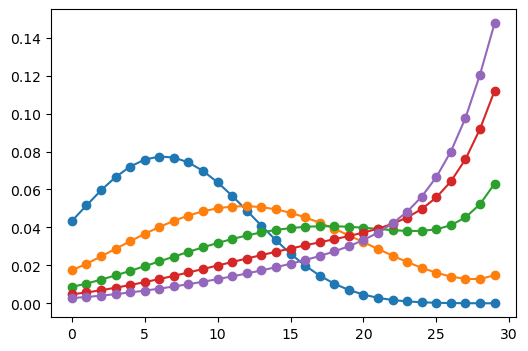

In [28]:
import quante as qt
import numpy as np

op = qt.generate.operas

L = 30
J = 1.
gamma_R = 1.0
gamma_L = 0.5

ham = op.builder()
for i in range(L-1):
    ham += "+-", [i+1, i], -J
    ham += "+-", [i, i+1], -J
ham = ham.build()

Lindblad_R = [np.sqrt(gamma_R) * op.pm(i+1,i) for i in range(L-1)]
Lindblad_L = [np.sqrt(gamma_L) * op.pm(i,i+1) for i in range(L-1)]
lind_ops = Lindblad_R + Lindblad_L
liou = op.super_oper.LiouvilleOper(L, ham, lind_ops)

basis = qt.generate.basis.spin_basis(L=L, Nup=1)
liou_mat = liou.to_matrix(basis=basis, pauli=False)

state = qt.generate.state.product_state(['up']+['dn']*(L-1), Nup=1)
rhoinit = np.outer(state, state)

particle_number_mat = [
    op.n(i).to_matrix(basis=basis, pauli=False, sparse=True).T.reshape(-1) 
    for i in range(L)
]
measure = lambda t, rho: np.real_if_close([n @ rho.reshape(-1) for n in particle_number_mat])

res = qt.linalg.evolve_and_measure(
    liou_mat, rhoinit, [10, 20, 30, 40, 50], 
    measure=measure, 
    ttype='imag-time',
    method='mul-cpu'
)

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(res.T, "o-");

不同方法的对比

In [33]:
import torch as tc

if tc.cuda.is_available():
    print("eig-cuda:0")
    res1 = qt.linalg.evolve_and_measure(
        liou_mat, rhoinit, [10, 20, 30, 40, 50], 
        measure=measure, 
        method='eig-cuda:0',
        ttype='imag-time',
    )
    print(np.linalg.norm(res1 - res))

print("mul-cpu")
res2 = qt.linalg.evolve_and_measure(
    liou_mat, rhoinit, [10, 20, 30, 40, 50], 
    measure=measure, 
    method='mul-cpu',
    ttype='imag-time',
)
print(np.linalg.norm(res2 - res))

if tc.cuda.is_available():
    print("mul-cuda:0")
    res3 = qt.linalg.evolve_and_measure(
        liou_mat, rhoinit, [10, 20, 30, 40, 50], 
        measure=measure, 
        method='mul-cuda:0',
        ttype='imag-time',
    )
    print(np.linalg.norm(res3 - res))

print("RK45")
res4 = qt.linalg.evolve_and_measure(
    liou_mat, rhoinit, [10, 20, 30, 40, 50], 
    measure=measure, 
    method='RK45',
    ttype='imag-time',
)
print(np.linalg.norm(res4 - res))

liou_lo = liou.to_linearoperator(basis=basis, pauli=False, sparse=True)

print("mul-cpu with lo")
res5 = qt.linalg.evolve_and_measure(
    liou_lo, rhoinit, [10, 20, 30, 40, 50], 
    measure=measure, 
    method='mul-cpu',
    ttype='imag-time',
)
print(np.linalg.norm(res5 - res))

print("RK45 with lo")
res6 = qt.linalg.evolve_and_measure(
    liou_lo, rhoinit, [10, 20, 30, 40, 50], 
    measure=measure, 
    method='RK45',
    ttype='imag-time',
)
print(np.linalg.norm(res6 - res))

mul-cpu


100%|##########| 5/5 [00:00<00:00, 39.94it/s]


0.0
RK45


100%|##########| 5/5 [00:00<00:00, 28.78it/s]

8.681300860163172e-11


mul-cpu with lo


100%|##########| 5/5 [00:02<00:00,  1.75it/s]


2.6074711161586197e-15
RK45 with lo


100%|##########| 5/5 [00:07<00:00,  1.59s/it]

8.731534859716793e-11


后面两种方法都使用 LinearOperator，如果使用 dense matrix 计算会快一些

In [34]:
liou_lo = liou.to_linearoperator(basis=basis, pauli=False, sparse=False)
res3 = qt.linalg.evolve_and_measure(
    liou_lo, rhoinit, [10, 20, 30, 40, 50], 
    measure=measure, 
    method='mul-cpu',
    ttype='imag-time',
)

res4 = qt.linalg.evolve_and_measure(
    liou_lo, rhoinit, [10, 20, 30, 40, 50], 
    measure=measure, 
    method='RK45',
    ttype='imag-time',
)

list(map(np.linalg.norm, [ res3 - res, res4 - res]))

100%|##########| 5/5 [00:02<00:00,  2.35it/s]


[np.float64(1.082231758151694e-15), np.float64(8.694777356194142e-11)]

稳态

In [40]:
res = liou.steady_state(basis=basis, pauli=False, method='direct')
measure(0, res)

array([0.00022988, 0.0002796 , 0.00035408, 0.00044866, 0.00056866, 0.0007208 , 0.00091366, 0.00115814, 0.00146803, 0.00186085, 0.00235878, 0.00298994, 0.00378998, 0.00480411, 0.00608959, 0.00771904, 0.00978449, 0.01240259, 0.01572123, 0.01992778, 0.02525976, 0.03201805, 0.04058375, 0.051439  , 0.0651927 , 0.08261014, 0.10464141, 0.13241707, 0.16698079, 0.20526746])

# Symmetry of Liouvillian

float64
float64


100%|##########| 5/5 [00:00<00:00, 86.87it/s]


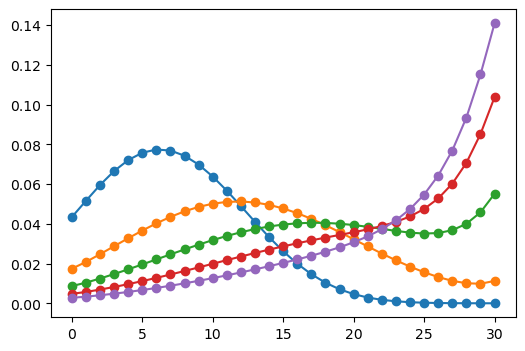

In [24]:
import quante as qt
import numpy as np

op = qt.generate.operas

L = 31
J = 1.
gamma_R = 1.0
gamma_L = 0.5

ham = op.builder()
for i in range(L-1):
    ham += "+-", [i+1, i], -J
    ham += "+-", [i, i+1], -J
ham = ham.build()

Lindblad_R = [np.sqrt(gamma_R) * op.pm(i+1,i) for i in range(L-1)]
Lindblad_L = [np.sqrt(gamma_L) * op.pm(i,i+1) for i in range(L-1)]
lind_ops = Lindblad_R + Lindblad_L
liou = op.super_oper.LiouvilleOper(L, ham, lind_ops)

basis = qt.generate.basis.spin_super_basis(L=L, Nup2=1)
liou_mat = liou.to_matrix(basis=basis, pauli=False)
print(liou_mat.dtype)

state = qt.generate.state.product_state(['up']+['dn']*(L-1), Nup=1)
rhoinit = basis.project(np.outer(state, state).reshape(-1), Nup2=1)
print(rhoinit.dtype)

basis0 = qt.generate.basis.spin_basis(L=L, Nup=1)
particle_number_mat = []
for i in range(L):
    n_i = op.n(i).to_matrix(basis=basis0, pauli=False, sparse=False).reshape(-1)
    n_i_proj = basis.project(n_i, Nup2=1).reshape(-1)
    particle_number_mat.append(n_i_proj)
measure = lambda t, rho: [n @ rho.reshape(-1) for n in particle_number_mat]

res = qt.linalg.evolve_and_measure(
    liou_mat, rhoinit, [10, 20, 30, 40, 50], 
    measure=measure, 
    ttype='imag-time',
    method='mul-cpu'
)

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(res.T, "o-");

## 不同方法的 benchmark

In [10]:
import quante as qt
L = 12
ham = qt.generate.operas.spin.heisenberg_operator(L)
basis = qt.generate.basis.spin_basis(L)
mat = ham.to_matrix(basis, pauli=False, sparse=True)
state = qt.generate.state.random(basis.Ns, seed=42)
qt.linalg.expm_multiply(mat, state, ttype='real-time', start=0, stop=10, num=100, herm=True);

In [11]:
import quante as qt
import numpy as np
import scipy.sparse as sp
import time

## 初始化态和哈密顿量

In [12]:
# 拿到矩阵
L = 12
ham = qt.generate.operas.spin.heisenberg_operator(L)
basis = qt.generate.basis.spin_basis(L)
mat = ham.to_matrix(basis, pauli=False, sparse=True)

# 拿到态
state = qt.generate.state.random(basis.Ns, seed=42)

## 比较不同方法的计算结果

### 用本征分解的方法计算

In [13]:
res = qt.linalg.eigh(mat)
times = np.linspace(0,10,100)
qt.linalg.get_time_evolution_states_ED(state,*res,times, device_name='cpu')

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

### 用 scipy 的 expm_multiply

In [14]:
res = sp.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100)
np.squeeze(res).T

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

### 使用 quante 的 expm_multiply

In [15]:
res = qt.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100)
np.squeeze(res).T

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

针对实矩阵的优化

In [16]:
res = qt.linalg.expm_multiply(mat, state, ttype='real-time', start=0, stop=10, num=100)
np.squeeze(res).T

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

## 比较运行速度

In [17]:
runlarge = False

生成一个较大的矩阵

In [18]:
if runlarge:
    # 拿到矩阵
    L = 18
    ham = qt.generate.operas.spin.heisenberg_operator(L)
    basis = qt.generate.basis.spin_basis(L)
    mat = ham.to_matrix(basis, sparse=True)
    print("space dimension:", basis.Ns)

    # 拿到态
    state = qt.generate.state.random(basis.Ns, seed=42)

比较四种方法运行所需要的时间

In [19]:
if runlarge:
    # 方法1:
    import scipy.sparse as sp

    t = time.time()
    res1 = sp.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100)
    print(f"time scipy.expm_multiple: {time.time()-t:.2f}s")

    t = time.time()
    res2 = qt.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100, herm=True)
    print(f"time quante.expm_multiple with cpu parallel: {time.time()-t:.2f}s")

    t = time.time()
    res3 = qt.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100, device='cuda:0', herm=True)
    print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

    t = time.time()
    res4 = qt.linalg.expm_multiply(mat, state, ttype='real-time', start=0, stop=10, num=100, device='cuda:0', herm=True)
    print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

    print("norm difference between first two:", np.allclose(res1, res2))
    print("norm difference between last two:", np.allclose(res2, res3))
    print("norm difference between last two:", np.allclose(res3, res4))

one result:
```text
time scipy.expm_multiple: 26.11s
time quante.expm_multiple with cpu parallel: 16.98s
time quante.expm_multiple with gpu cuda: 2.52s
time quante.expm_multiple with gpu cuda: 1.28s
norm difference between first two: True
norm difference between last two: True
norm difference between last two: True
```

建一个更大的矩阵

In [20]:
if runlarge:
    L = 22
    ham = qt.generate.operas.spin.heisenberg_operator(L)
    basis = qt.generate.basis.spin_basis(L)
    mat = ham.to_matrix(basis, sparse=True)
    print("space dimension:", basis.Ns)

    # 拿到态
    state = qt.generate.state.random(basis.Ns, seed=42)

演化 1s 需要的时间

In [21]:
if runlarge:
    # 方法1:
    t = time.time()
    res1 = sp.linalg.expm_multiply((-1j*mat), state)
    print(f"time scipy.expm_multiple: {time.time()-t:.2f}s")

    t = time.time()
    res2 = qt.linalg.expm_multiply((-1j*mat), state, herm=True)
    print(f"time quante.expm_multiple with cpu parallel: {time.time()-t:.2f}s")

    t = time.time()
    res3 = qt.linalg.expm_multiply((-1j*mat), state, device='cuda:0', herm=True)
    print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

    t = time.time()
    res4 = qt.linalg.expm_multiply(mat, state, ttype='real-time', device='cuda:0', herm=True)
    print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

    print("norm difference between first two:", np.allclose(res1, res2))
    print("norm difference between last two:", np.allclose(res1, res3))
    print("norm difference between last two:", np.allclose(res1, res4))

one result:
```text
time scipy.expm_multiple: 16.74s
time quante.expm_multiple with cpu parallel: 9.79s
time quante.expm_multiple with gpu cuda: 2.21s
time quante.expm_multiple with gpu cuda: 1.27s
norm difference between first two: True
norm difference between last two: True
norm difference between last two: True
```

所能运行的最大尺寸

In [22]:
if runlarge:
    # 拿到矩阵
    L = 26
    ham = qt.generate.operas.spin.heisenberg_operator(L)
    ham = ham.expandxy()
    basis = qt.generate.basis.spin_basis(L)
    t = time.time()
    mat = ham.to_matrix(basis, sparse=True)
    print(f"time to generate matrix: {time.time()-t:.2f}s")

    print("space dimension:", basis.Ns)

    # 拿到态
    state = qt.generate.state.random(basis.Ns, seed=42)

    t = time.time()
    res3 = qt.linalg.expm_multiply(mat, state, ttype='real-time', device='cuda:0', herm=True)
    print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

```text
time to generate matrix: 41.90s
space dimension: 67108864
time quante.expm_multiple with gpu cuda: 22.14s
```

In [23]:
if runlarge:
    print(f"哈密顿量内存占用：",end="")
    qt.basicfun.print_memory_usage(mat)
    print(f"演化态内存占用：",end="");
    qt.basicfun.print_memory_usage(res3)

```text
哈密顿量内存占用：10.38 GB
演化态内存占用：1.00 GB
```